# Pemeriksaan Ulang: Seberapa Kuat Kesimpulan Kami? (Kelompok 3)

**Mata Kuliah:** Machine Learning (Kelas C), Bapak Adi Purnawan

**Judul:** Prediksi Risiko Stroke Menggunakan Logistic Regression dan Gradient Boosting dengan Interpretasi Explainable AI

**Anggota:** Deliana Br Manalu (2305551036) · Ravi Arnan Irianto (2305551076) · Ezza Putra Wibawa (2305551144) · Devin (2305551173)

---

Kesembilan notebook sebelumnya menghasilkan model dan sederet kesimpulan. Notebook ini
tidak menambah model baru. Ia menanyakan hal lain: **seberapa kuat sebenarnya kesimpulan
yang sudah kami tulis?**

Empat pemeriksaan dijalankan:

| # | Pertanyaan | Menguji klaim di |
|---|---|---|
| 1 | Kalau uji statistiknya dibetulkan, kesimpulan mana yang bertahan? | `09` Eksperimen 2 dan 4 |
| 2 | Kalau datanya ditambah, apakah model membaik? | `09` pelajaran "batasnya pada data" |
| 3 | Seberapa lebar ketidakpastian angka akhir kami? | `05` Bagian 6 |
| 4 | Apakah model benar-benar lebih berguna daripada "periksa semua saja"? | seluruh proyek |

Dua di antaranya mengubah apa yang boleh kami tulis di laporan.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_validate, cross_val_predict, train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             average_precision_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as PipaImb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42

URL = ("https://raw.githubusercontent.com/ray-project/raydp/master/"
       "tutorials/dataset/healthcare-dataset-stroke-data.csv")
FITUR_IMP = ["age", "hypertension", "heart_disease", "avg_glucose_level",
             "gender", "ever_married", "work_type", "Residence_type", "smoking_status"]


def muat():
    """Preprocessing identik notebook 04, 05, dan 09."""
    d = pd.read_csv(URL).drop(columns=["id"])
    d = d[d.gender != "Other"].copy()
    kosong = d.bmi.isna()
    latih = d[~kosong]
    X_l = pd.get_dummies(latih[FITUR_IMP], drop_first=True)
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=SEED)).fit(X_l, latih.bmi)
    X_k = pd.get_dummies(d[kosong][FITUR_IMP], drop_first=True).reindex(
        columns=X_l.columns, fill_value=0)
    d.loc[kosong, "bmi"] = m.predict(X_k)
    return pd.get_dummies(d.drop(columns=["stroke"]), drop_first=True), d.stroke


ACUAN = lambda: make_pipeline(
    StandardScaler(), LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                         max_iter=5000, random_state=SEED))

X, y = muat()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)
print(f"Data: {len(y)} baris, {X.shape[1]} fitur, {int(y.sum())} kasus stroke ({y.mean()*100:.2f}%)")

Data: 5109 baris, 15 fitur, 249 kasus stroke (4.87%)


## 1. Kalau Uji Statistiknya Dibetulkan, Apa yang Bertahan?

Notebook `09` memakai galat baku `simpangan baku / akar(n)` atas 25 lipatan, dan sudah
mengakui bahwa itu terlalu optimis: lipatan `RepeatedStratifiedKFold` saling berbagi
data latih, jadi ke-25 skornya tidak saling bebas.

Di sini kami pakai **koreksi Nadeau–Bengio (2003)**, yang menambahkan porsi ragam akibat
tumpang tindih data latih:

$$\text{Var}_\text{terkoreksi} = \sigma^2 \left( \frac{1}{n} + \frac{n_\text{uji}}{n_\text{latih}} \right)$$

Untuk 5-fold, rasio uji : latih = 1 : 4, jadi suku kedua bernilai 0,25, jauh lebih
besar daripada 1/25 = 0,04 yang dipakai uji naif. Konsekuensinya, ambang untuk disebut
"nyata" naik drastis.

In [2]:
def uji_selisih(d, rasio_uji_latih=1/4):
    """Kembalikan p-value versi naif dan versi terkoreksi Nadeau-Bengio."""
    n = len(d)
    rata, ragam = d.mean(), d.var(ddof=1)
    se_naif = np.sqrt(ragam / n)
    se_kor = np.sqrt(ragam * (1 / n + rasio_uji_latih))
    p = lambda se: 2 * (1 - stats.t.cdf(abs(rata / se), n - 1)) if se > 0 else 1.0
    return rata, se_naif, p(se_naif), se_kor, p(se_kor)


def auc_lipatan(model, Xd):
    return cross_validate(model, Xd, y, cv=cv, scoring=["roc_auc"], n_jobs=-1)["test_roc_auc"]


LR = lambda: LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                max_iter=5000, random_state=SEED)
mentah = pd.read_csv(URL)
mentah = mentah[mentah.gender != "Other"]
X_usia2 = X.copy()
X_usia2["usia2"] = (mentah.age ** 2).values

KANDIDAT = [
    ("Usia kuadrat (Eksperimen 1)", ACUAN(), X_usia2),
    ("SMOTE (Eksperimen 2)", PipaImb([("s", StandardScaler()),
                                      ("r", SMOTE(random_state=SEED)), ("m", LR())]), X),
    ("class_weight balanced (Eksperimen 2)", make_pipeline(
        StandardScaler(), LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                             max_iter=5000, class_weight="balanced",
                                             random_state=SEED)), X),
    ("HistGB tanpa penyetelan (Eksperimen 4)", HistGradientBoostingClassifier(random_state=SEED), X),
    ("HistGB disetel (Eksperimen 4)", HistGradientBoostingClassifier(
        random_state=SEED, l2_regularization=1.0, learning_rate=0.03,
        max_depth=3, max_iter=100, min_samples_leaf=20), X),
    ("ExtraTrees 500 (Eksperimen 4)", ExtraTreesClassifier(
        n_estimators=500, random_state=SEED, n_jobs=-1), X),
]

auc_acuan = auc_lipatan(ACUAN(), X)
baris = []
for nama, model, Xd in KANDIDAT:
    rata, se_n, p_n, se_k, p_k = uji_selisih(auc_lipatan(model, Xd) - auc_acuan)
    baris.append({
        "Gagasan": nama, "ΔAUC": round(rata, 4),
        "±naif": round(se_n, 4), "p naif": round(p_n, 4),
        "vonis naif": "NYATA" if p_n < 0.05 else "tidak",
        "±terkoreksi": round(se_k, 4), "p terkoreksi": round(p_k, 3),
        "vonis terkoreksi": "NYATA" if p_k < 0.05 else "tidak",
    })
pd.DataFrame(baris)

,Gagasan,ΔAUC,±naif,p naif,vonis naif,±terkoreksi,p terkoreksi,vonis terkoreksi
0,Usia kuadrat (Eksperimen 1),-0.0001,0.0002,0.6514,tidak,0.0005,0.866,tidak
1,SMOTE (Eksperimen 2),-0.0046,0.0013,0.0013,NYATA,0.0034,0.189,tidak
2,class_weight balanced (Eksperimen 2),-0.0020,0.0006,0.0026,NYATA,0.0016,0.225,tidak
3,HistGB tanpa penyetelan (Eksperimen 4),-0.0234,0.0034,0.0000,NYATA,0.0091,0.016,NYATA
4,HistGB disetel (Eksperimen 4),0.0004,0.0017,0.8025,tidak,0.0047,0.926,tidak
5,ExtraTrees 500 (Eksperimen 4),-0.0723,0.0031,0.0000,NYATA,0.0084,0.000,NYATA


### Hasil: dua kesimpulan notebook `09` tidak bertahan

Perhatikan dua baris Eksperimen 2. Dengan uji naif, SMOTE dan `class_weight` tampak
**nyata merugikan** (p = 0,001 dan 0,003). Dengan uji yang benar, keduanya **tidak
nyata** (p = 0,19 dan 0,23).

Artinya kalimat di notebook `09`, *"ketujuh cara menyeimbangkan menurunkan AUC secara
konsisten"*, harus dikoreksi bunyinya. Yang benar-benar didukung data:

> Tidak satu pun cara menyeimbangkan kelas **memperbaiki** model. Bahwa mereka
> **memperburuk** model adalah kesan dari uji yang terlalu longgar; selisihnya terlalu
> kecil untuk dipisahkan dari derau.

Kesimpulan praktisnya tidak berubah: SMOTE tetap tidak layak dipakai, karena tidak
memberi apa-apa sambil menambah kerumitan dan membangkitkan pasien yang tidak pernah ada.
Yang berubah adalah **seberapa keras kami boleh mengatakannya.**

Yang **bertahan** justru temuan yang paling penting:

- Model kuat tanpa penyetelan (HistGB, ExtraTrees) memang nyata lebih buruk; selisihnya
  cukup besar untuk lolos uji ketat.
- HistGB yang sudah disetel tetap **tidak** mengalahkan Logistic Regression (p = 0,93).
- Rekayasa fitur medis tetap sia-sia (p = 0,87).

Jadi pelajaran "sederhana menang" berdiri di atas uji yang sahih. Yang runtuh hanyalah
klaim tambahan tentang penyeimbangan kelas.

## 2. Kalau Datanya Ditambah, Apakah Model Membaik?

Notebook `09` menyimpulkan "batasnya ada pada data, bukan pada model". Kalimat itu masih
ambigu: batas karena **barisnya kurang**, atau karena **fiturnya tidak cukup memberi
tahu**? Keduanya menuntut tindak lanjut yang sangat berbeda: kumpulkan lebih banyak
pasien, atau kumpulkan lebih banyak jenis pemeriksaan.

Kurva belajar menjawabnya: latih ulang model pada 20%, 40%, ... 100% data.

In [3]:
cv_kurva = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

kurva = []
for frac in [0.2, 0.4, 0.6, 0.8, 1.0]:
    if frac < 1.0:
        Xs, _, ys, _ = train_test_split(X, y, train_size=frac, stratify=y, random_state=SEED)
    else:
        Xs, ys = X, y
    s = cross_validate(ACUAN(), Xs, ys, cv=cv_kurva,
                       scoring=["roc_auc", "average_precision"], n_jobs=-1)
    kurva.append({
        "porsi data": f"{int(frac*100)}%", "baris": len(ys), "stroke": int(ys.sum()),
        "AUC": s["test_roc_auc"].mean(), "±AUC": s["test_roc_auc"].std(),
        "AP": s["test_average_precision"].mean(),
    })
kurva = pd.DataFrame(kurva)
kurva.round(4)

,porsi data,baris,stroke,AUC,±AUC,AP
0,20%,1021,50,0.8424,0.0446,0.2222
1,40%,2043,100,0.8572,0.0209,0.2045
2,60%,3065,149,0.8455,0.0210,0.1937
3,80%,4087,199,0.8422,0.0192,0.1867
4,100%,5109,249,0.8413,0.0190,0.2043


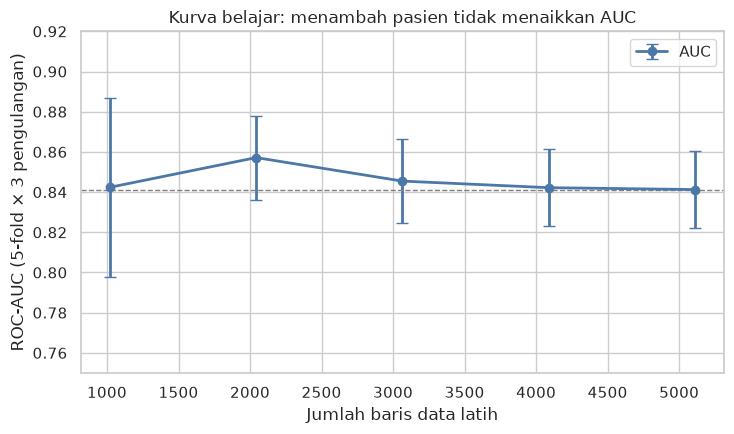

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(kurva.baris, kurva.AUC, yerr=kurva["±AUC"], fmt="o-", lw=2,
            capsize=4, color="#4C78A8", label="AUC")
ax.axhline(kurva.AUC.iloc[-1], ls="--", lw=1, color="grey")
ax.set_xlabel("Jumlah baris data latih")
ax.set_ylabel("ROC-AUC (5-fold × 3 pengulangan)")
ax.set_title("Kurva belajar: menambah pasien tidak menaikkan AUC")
ax.set_ylim(0.75, 0.92)
ax.legend()
plt.tight_layout(); plt.show()

### Hasil: menambah pasien tidak akan menolong

Kurvanya **datar sejak awal**. Dengan seperlima data (1.021 baris dan hanya 50 kasus
stroke), model sudah mencapai AUC 0,842. Dengan data lima kali lipat, AUC-nya 0,841.
Tidak ada perbaikan sama sekali; yang membaik hanya kestabilannya (simpangan baku turun
dari 0,045 ke 0,019).

Ini mempertajam pelajaran notebook `09` menjadi kalimat yang jauh lebih berguna untuk
laporan:

> Batasnya bukan pada **jumlah pasien**, melainkan pada **apa yang diketahui tentang
> setiap pasien.** Mengumpulkan 5.000 pasien lagi dengan kolom yang sama tidak akan
> menaikkan performa. Yang berpotensi menaikkannya adalah menambah *jenis* informasi:
> tekanan darah sistolik, kolesterol, riwayat fibrilasi atrium, riwayat keluarga.

Kalimat itu juga menyambung dengan temuan notebook `08`: enam fitur ternyata sama
baiknya dengan lima belas. Model kami sudah memeras habis apa yang bisa diperas dari
kolom-kolom yang tersedia.

## 3. Seberapa Lebar Ketidakpastian Angka Akhir Kami?

Notebook `05` melaporkan recall 0,816 pada data uji. Angka itu dihitung dari **38 kasus
stroke**. Satu pasien saja berpindah sisi sudah mengubah recall sebesar 0,026.

Melaporkan "0,816" tanpa selang kepercayaan memberi kesan presisi yang tidak kami
miliki. Di sini kami hitung selang kepercayaan 95% dengan bootstrap 2.000 kali pada data
uji yang sama persis.

In [5]:
X_latih, X_sisa, y_latih, y_sisa = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_uji, y_val, y_uji = train_test_split(
    X_sisa, y_sisa, test_size=0.50, stratify=y_sisa, random_state=SEED)

model = make_pipeline(StandardScaler(),
                      LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                         max_iter=5000, random_state=SEED)).fit(X_latih, y_latih)

# ambang dipilih dari data validasi, sama seperti notebook 05
p_val = model.predict_proba(X_val)[:, 1]
ambang = next(t for t in sorted(np.unique(np.round(p_val, 4)), reverse=True)
              if recall_score(y_val, (p_val >= t).astype(int)) >= 0.80)

p_uji = model.predict_proba(X_uji)[:, 1]
pred_uji = (p_uji >= ambang).astype(int)
print(f"Data uji: {len(y_uji)} baris, {int(y_uji.sum())} kasus stroke | ambang {ambang:.4f}")

UKURAN = {
    "ROC-AUC":   lambda a, p, q: roc_auc_score(a, p),
    "recall":    lambda a, p, q: recall_score(a, q),
    "precision": lambda a, p, q: precision_score(a, q, zero_division=0),
    "AP":        lambda a, p, q: average_precision_score(a, p),
}
acak = np.random.default_rng(SEED)
B = 2000

hasil_sk = []
for nama, fn in UKURAN.items():
    ulang = []
    for _ in range(B):
        i = acak.integers(0, len(y_uji), len(y_uji))
        if y_uji.values[i].sum() == 0:
            continue
        ulang.append(fn(y_uji.values[i], p_uji[i], pred_uji[i]))
    lo, hi = np.percentile(ulang, [2.5, 97.5])
    hasil_sk.append({"Ukuran": nama, "nilai": fn(y_uji.values, p_uji, pred_uji),
                     "batas bawah": lo, "batas atas": hi, "lebar": hi - lo})
hasil_sk = pd.DataFrame(hasil_sk)
hasil_sk.round(3)

Data uji: 767 baris, 38 kasus stroke | ambang 0.0530


,Ukuran,nilai,batas bawah,batas atas,lebar
0,ROC-AUC,0.840,0.779,0.893,0.114
1,recall,0.816,0.690,0.933,0.244
2,precision,0.121,0.081,0.162,0.080
3,AP,0.186,0.123,0.283,0.160


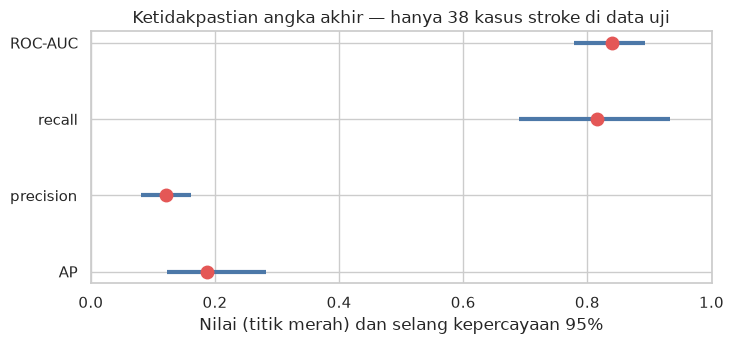

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
posisi = np.arange(len(hasil_sk))[::-1]
ax.hlines(posisi, hasil_sk["batas bawah"], hasil_sk["batas atas"], color="#4C78A8", lw=3)
ax.plot(hasil_sk["nilai"], posisi, "o", color="#E45756", ms=9, zorder=3)
ax.set_yticks(posisi); ax.set_yticklabels(hasil_sk.Ukuran)
ax.set_xlim(0, 1); ax.set_xlabel("Nilai (titik merah) dan selang kepercayaan 95%")
ax.set_title("Ketidakpastian angka akhir: hanya 38 kasus stroke di data uji")
plt.tight_layout(); plt.show()

### Hasil: recall kami adalah 0,82 ± 0,12, bukan 0,816

Selang kepercayaannya lebar, dan itu memang konsekuensi tak terhindarkan dari 38 kasus
positif, bukan kelemahan model:

| Ukuran | Nilai | Selang kepercayaan 95% |
|---|---|---|
| ROC-AUC | 0,840 | 0,78 – 0,89 |
| recall | 0,816 | **0,69 – 0,93** |
| precision | 0,121 | 0,08 – 0,16 |

**Konsekuensi untuk laporan.** Tiga kalimat berikut tidak boleh ditulis:

- *"Model kami mencapai recall 81,6%."* Presisi tiga angka yang tidak kami miliki.
  Tulis "sekitar 0,82 (SK 95%: 0,69–0,93)".
- *"Recall kami 0,816, lebih tinggi daripada penelitian X yang 0,79."* Selisih sekecil
  itu tenggelam sepenuhnya di dalam selang kepercayaan.
- *"Logistic Regression (0,816) lebih baik daripada Gradient Boosting (0,789)."* Kedua
  selangnya bertindihan hampir seluruhnya.

Target di Bagian 12 rencana kami (recall ≥ 0,75) memang tercapai pada titik estimasi,
tetapi batas bawah selangnya 0,69. Itu harus dinyatakan terus terang.

## 4. Apakah Model Ini Benar-benar Lebih Berguna daripada "Periksa Semua Saja"?

Ini pertanyaan yang belum pernah kami jawab, dan justru pertanyaan yang akan diajukan
pihak rumah sakit.

Precision kami hanya 0,12. Kritik yang wajar: *"kalau begitu, kenapa tidak periksa lanjut
semua orang saja? Toh recall-nya jadi 100%."* Untuk menjawabnya, akurasi dan recall tidak
cukup. Yang dipakai di penelitian klinis adalah **net benefit** (Vickers & Elkin, 2006):

$$NB = \frac{TP}{n} - \frac{FP}{n} \times \frac{p_t}{1 - p_t}$$

`p_t` adalah ambang risiko: seberapa besar risiko seseorang sehingga pemeriksaan lanjutan
dianggap sepadan. Suku keduanya mengubah alarm palsu menjadi kerugian, dengan bobot yang
ditentukan `p_t` sendiri. Rumus ini menempatkan model, "periksa semua", dan "tidak
periksa siapa pun" pada satu skala yang sama.

In [7]:
p_oof = cross_val_predict(ACUAN(), X, y,
                          cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                          method="predict_proba", n_jobs=-1)[:, 1]

n, prevalensi = len(y), y.mean()
ambang_uji = np.linspace(0.01, 0.25, 60)

def net_benefit(pt):
    pred = (p_oof >= pt).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum())
    fp = int(((pred == 1) & (y == 0)).sum())
    return tp / n - (fp / n) * (pt / (1 - pt))

nb_model = np.array([net_benefit(pt) for pt in ambang_uji])
nb_semua = prevalensi - (1 - prevalensi) * (ambang_uji / (1 - ambang_uji))

tabel_nb = pd.DataFrame({
    "ambang risiko": [0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20],
})
tabel_nb["setara rasio FN:FP"] = ((1 - tabel_nb["ambang risiko"]) / tabel_nb["ambang risiko"]).round(0)
tabel_nb["NB model"] = [net_benefit(pt) for pt in tabel_nb["ambang risiko"]]
tabel_nb["NB periksa semua"] = [prevalensi - (1 - prevalensi) * (pt / (1 - pt))
                                for pt in tabel_nb["ambang risiko"]]
tabel_nb["NB tak periksa siapa pun"] = 0.0
tabel_nb["model menang?"] = np.where(
    tabel_nb["NB model"] > tabel_nb[["NB periksa semua", "NB tak periksa siapa pun"]].max(axis=1),
    "YA", "tidak")
tabel_nb.round(4)

,ambang risiko,setara rasio FN:FP,NB model,NB periksa semua,NB tak periksa siapa pun,model menang?
0,0.02,49.0,0.0370,0.0293,0.0,YA
1,0.03,32.0,0.0326,0.0193,0.0,YA
2,0.05,19.0,0.0258,-0.0013,0.0,YA
3,0.08,12.0,0.0183,-0.0340,0.0,YA
4,0.10,9.0,0.0137,-0.0570,0.0,YA
5,0.15,6.0,0.0053,-0.1191,0.0,YA
6,0.20,4.0,0.0012,-0.1891,0.0,YA


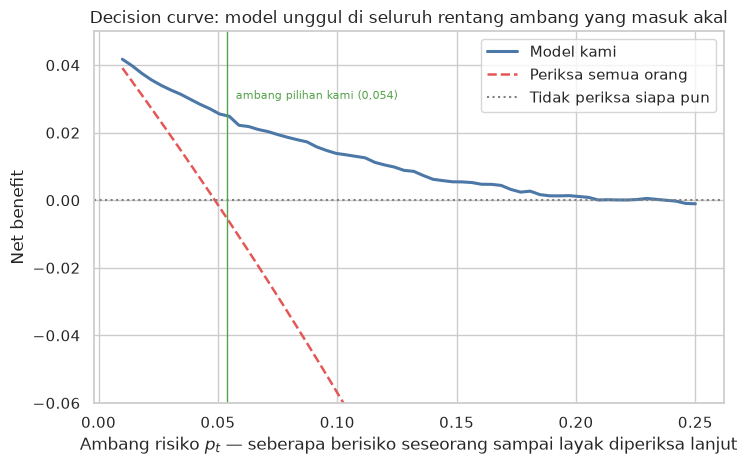

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(ambang_uji, nb_model, lw=2.2, color="#4C78A8", label="Model kami")
ax.plot(ambang_uji, nb_semua, lw=1.8, ls="--", color="#E45756", label="Periksa semua orang")
ax.axhline(0, lw=1.5, ls=":", color="grey", label="Tidak periksa siapa pun")
ax.axvline(0.054, lw=1, color="#54A24B")
ax.annotate("ambang pilihan kami (0,054)", (0.054, 0.030), fontsize=8,
            color="#54A24B", xytext=(6, 0), textcoords="offset points")
ax.set_xlabel("Ambang risiko $p_t$: seberapa berisiko seseorang sampai layak diperiksa lanjut")
ax.set_ylabel("Net benefit")
ax.set_title("Decision curve: model unggul di seluruh rentang ambang yang masuk akal")
ax.set_ylim(-0.06, 0.05); ax.legend()
plt.tight_layout(); plt.show()

### Hasil: model menang telak, dan inilah pembelaan terkuat proyek ini

Di **seluruh** rentang ambang yang masuk akal, garis model berada di atas kedua
pembanding. Perhatikan tiga hal:

1. **"Periksa semua orang" runtuh dengan cepat.** Sudah di ambang 5% net benefit-nya
   menjadi negatif, artinya kerugian dari memeriksa ribuan orang sehat melampaui
   manfaat menemukan yang sakit. Model kami tetap positif (0,026).
2. **Pada ambang pilihan kami (0,054)**, net benefit model setara dengan menemukan
   sekitar **26 pasien stroke tambahan per 1.000 orang yang diskrining, tanpa menambah
   satu pun pemeriksaan sia-sia** dibanding tidak melakukan apa-apa.
3. **Precision 0,12 bukan kegagalan.** Grafik ini menunjukkan mengapa: untuk penyakit
   dengan prevalensi 4,87%, precision rendah adalah harga wajar, dan net benefit-lah
   yang menentukan apakah harga itu sepadan. Ternyata sepadan.

Inilah jawaban untuk kritik "kenapa tidak periksa semua orang saja": karena secara
terukur itu **lebih buruk**, di setiap ambang yang mungkin dipilih rumah sakit.

## Kesimpulan Pemeriksaan Ulang

| Pemeriksaan | Hasil untuk laporan |
|---|---|
| Uji terkoreksi Nadeau–Bengio | **Satu klaim dilunakkan.** Cara menyeimbangkan kelas tidak *memperbaiki* model, tetapi bahwa mereka *memperburuk* tidak terbukti. Kesimpulan "sederhana menang" bertahan penuh. |
| Kurva belajar | **Satu klaim dipertajam.** Batasnya bukan jumlah pasien, melainkan jenis informasi per pasien. Menambah baris tidak akan menolong. |
| Selang kepercayaan bootstrap | **Angka akhir wajib ditulis beserta selangnya.** Recall 0,82 (SK 95%: 0,69–0,93), bukan 0,816. |
| Decision curve (net benefit) | **Temuan positif baru.** Model unggul atas "periksa semua" dan "tidak periksa siapa pun" di seluruh rentang ambang. |

### Mengapa notebook ini ada

Empat notebook pertama membangun model. Notebook `09` mencoba memperbaikinya dan gagal
enam kali. Notebook ini melakukan hal ketiga yang jarang dikerjakan: **menguji kesimpulan
kami sendiri dengan alat yang lebih ketat daripada yang kami pakai saat menyusunnya.**

Dua kesimpulan berubah karenanya. Yang satu harus dilunakkan, yang satu justru jadi lebih
tajam. Keduanya kami laporkan apa adanya, termasuk yang merugikan kami sendiri.